# Predicting Online Purchase Intent\n## A KNN-Based Approach to Customer Behaviour Modeling **Student Name:** Aryash Gupta  **Project:** Machine Learning - Customer Purchase Prediction

## Step 1: Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ML - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# ML - Metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_score,
    recall_score, f1_score
)

# Class Imbalance
from imblearn.over_sampling import SMOTE

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


In [2]:
# Load dataset
url = "https://samatrix-data.s3.ap-south-1.amazonaws.com/ML/online_shoppers_intention.csv"
data = pd.read_csv(url)

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {data.shape[0]} rows × {data.shape[1]} columns")
data.head()

DATASET OVERVIEW

Shape: 12330 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# Dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
# Check missing values
print("Missing Values:")
print("Total:", data.isnull().sum().sum())

Missing Values:
Total: 0


In [5]:
# Target distribution
print("Revenue Distribution:")
print(data["Revenue"].value_counts())
ratio = data["Revenue"].value_counts()[False] / data["Revenue"].value_counts()[True]
print(f"\nImbalance Ratio: {ratio:.2f}:1")

Revenue Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Imbalance Ratio: 5.46:1


In [6]:
# Create copy
df = data.copy()

# Encode Month
le_month = LabelEncoder()
df['Month'] = le_month.fit_transform(df['Month'])
print("✓ Month encoded")

# Encode VisitorType
le_visitor = LabelEncoder()
df['VisitorType'] = le_visitor.fit_transform(df['VisitorType'])
print("✓ VisitorType encoded")

# Convert Boolean to int
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Weekend and Revenue converted to integers")

df[['Month', 'VisitorType', 'Weekend', 'Revenue']].head()

✓ Month encoded
✓ VisitorType encoded
✓ Weekend and Revenue converted to integers


,Month,VisitorType,Weekend,Revenue
0,2,2,0,0
1,2,2,0,0
2,2,2,0,0
3,2,2,0,0
4,2,2,1,0


In [7]:
# Separate X and y
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")
print(f"\nTrain - Class 0: {(y_train==0).sum()}, Class 1: {(y_train==1).sum()}")
print(f"Test  - Class 0: {(y_test==0).sum()}, Class 1: {(y_test==1).sum()}")

Training: 9864 samples
Testing: 2466 samples

Train - Class 0: 8338, Class 1: 1526
Test  - Class 0: 2084, Class 1: 382


In [8]:
# Initialize scaler
scaler = StandardScaler()

# Fit on train, transform both
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled (mean=0, std=1)")

✓ Features scaled (mean=0, std=1)


---\n## Step 6: Logistic Regression (Baseline)

In [10]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]


print("Logistic Regression:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  ROC AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression:
  Accuracy:  0.8832
  Precision: 0.7640
  Recall:    0.3560
  ROC AUC:   0.8653

Confusion Matrix:
[[2042   42]
 [ 246  136]]


In [11]:
# Test with noise features
noise_levels = [0, 10, 25, 50, 100, 200]
accuracies_noise = []

for n_noise in noise_levels:
    if n_noise == 0:
        X_tr_n, X_te_n = X_train_scaled, X_test_scaled
    else:
        np.random.seed(42)
        noise_tr = np.random.randn(X_train_scaled.shape[0], n_noise)
        noise_te = np.random.randn(X_test_scaled.shape[0], n_noise)
        X_tr_n = np.hstack([X_train_scaled, noise_tr])
        X_te_n = np.hstack([X_test_scaled, noise_te])

    knn_noise = KNeighborsClassifier(n_neighbors=5)
    knn_noise.fit(X_tr_n, y_train)
    acc = accuracy_score(y_test, knn_noise.predict(X_te_n))
    accuracies_noise.append(acc)
    print(f"Noise={n_noise:3d} → Accuracy: {acc:.4f}")

print(f"\n❌ Degradation: {accuracies_noise[0]-accuracies_noise[-1]:.4f}")

Noise=  0 → Accuracy: 0.8678
Noise= 10 → Accuracy: 0.8646
Noise= 25 → Accuracy: 0.8548
Noise= 50 → Accuracy: 0.8512
Noise=100 → Accuracy: 0.8467
Noise=200 → Accuracy: 0.8463

❌ Degradation: 0.0215


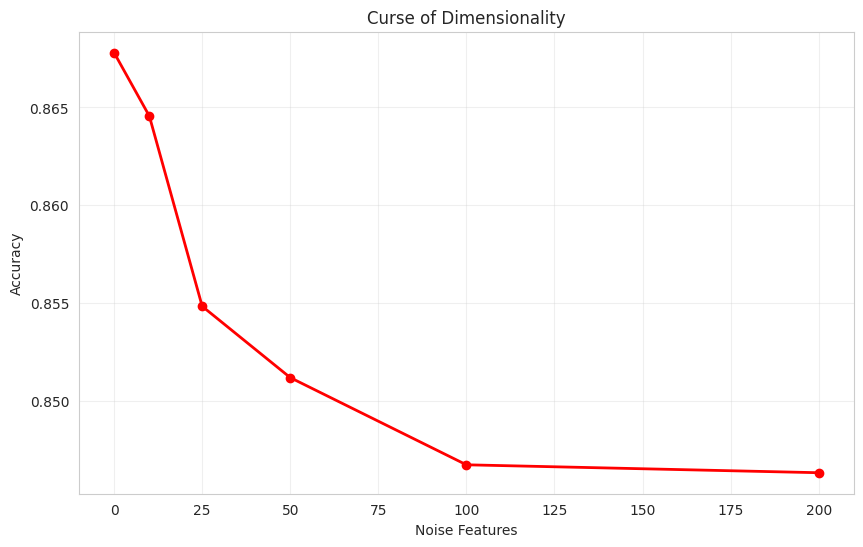

In [12]:
# Plot curse of dimensionality
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, accuracies_noise, marker='o', linewidth=2, color='red')
plt.xlabel('Noise Features')
plt.ylabel('Accuracy')
plt.title('Curse of Dimensionality')
plt.grid(True, alpha=0.3)
plt.show()

---\n## Step 8: KNN Hyperparameter Tuning

In [13]:
# Find optimal K
k_range = range(1, 31)
train_accs, test_accs, cv_scores = [], [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Cross-validation
    cv_scores.append(cross_val_score(knn, X_train_scaled, y_train, cv=5).mean())

    # Train and test accuracy
    knn.fit(X_train_scaled, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

optimal_k = k_range[np.argmax(cv_scores)]
print(f"✓ Optimal K = {optimal_k}")
print(f"  CV Score: {max(cv_scores):.4f}")
print(f"  Test Acc: {test_accs[optimal_k-1]:.4f}")

✓ Optimal K = 7
  CV Score: 0.8813
  Test Acc: 0.8783


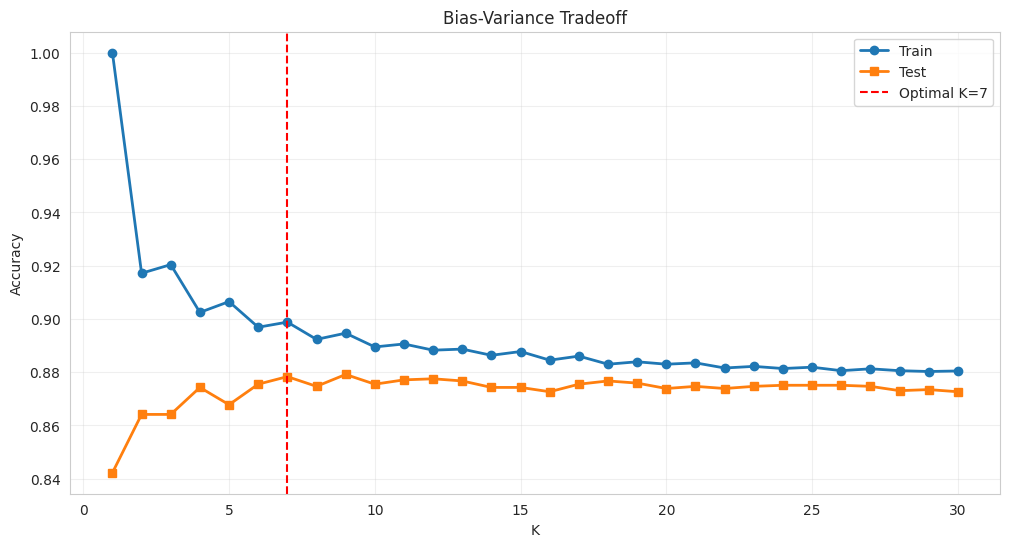

In [14]:
# Plot bias-variance tradeoff
plt.figure(figsize=(12, 6))
plt.plot(k_range, train_accs, label='Train', marker='o', linewidth=2)
plt.plot(k_range, test_accs, label='Test', marker='s', linewidth=2)
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---\n## Step 9: Train Final KNN Model

In [15]:
# Train KNN with optimal K
knn_best = KNeighborsClassifier(n_neighbors=optimal_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print(f"KNN (K={optimal_k}):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_knn):.4f}")
print(f"  ROC AUC:   {roc_auc_score(y_test, y_prob_knn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN (K=7):
  Accuracy:  0.8783
  Precision: 0.6990
  Recall:    0.3770
  ROC AUC:   0.7990

Confusion Matrix:
[[2022   62]
 [ 238  144]]


---\n## Step 10: Train Other Models

In [16]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  ROC AUC:  {roc_auc_score(y_test, y_prob_dt):.4f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\nRandom Forest:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  ROC AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")

Decision Tree:
  Accuracy: 0.8532
  ROC AUC:  0.7293

Random Forest:
  Accuracy: 0.9006
  ROC AUC:  0.9183


---\n## Step 11: Model Comparison

In [17]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Logistic Reg', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ]
})

print(comparison)

           Model  Accuracy   ROC AUC    Recall
0   Logistic Reg  0.883212  0.865257  0.356021
1            KNN  0.878345  0.798979  0.376963
2  Decision Tree  0.853204  0.729284  0.549738
3  Random Forest  0.900649  0.918283  0.560209


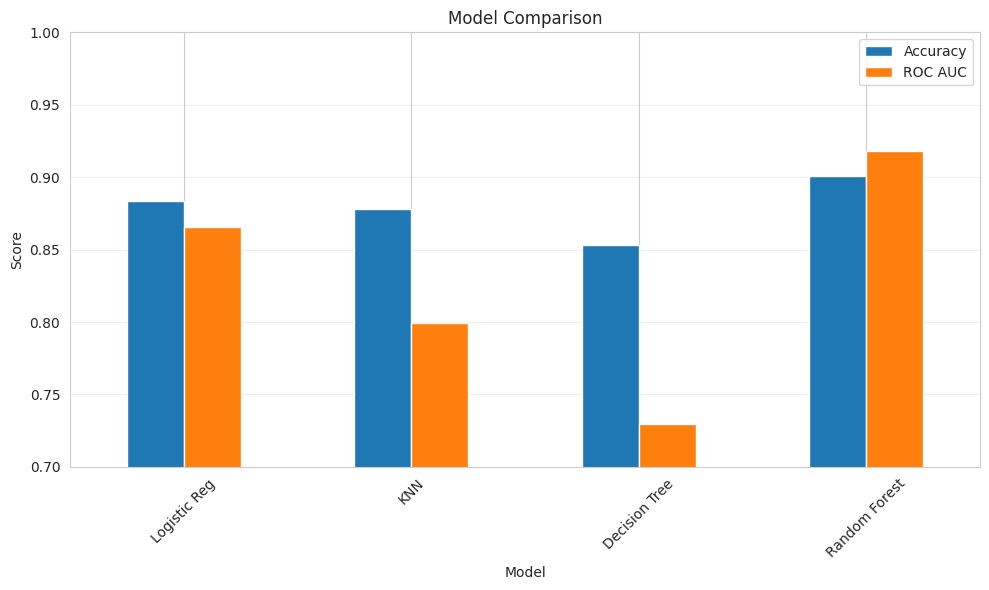

In [18]:
# Visualize comparison
comparison.set_index('Model')[['Accuracy', 'ROC AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim([0.7, 1.0])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---\n## Step 12: Apply PCA

In [19]:

pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = np.argmax(explained_var >= 0.95) + 1

print(f"Components for 95% variance: {n_comp_95}")
print(f"Variance explained: {explained_var[n_comp_95-1]:.4f}")

Components for 95% variance: 14
Variance explained: 0.9679


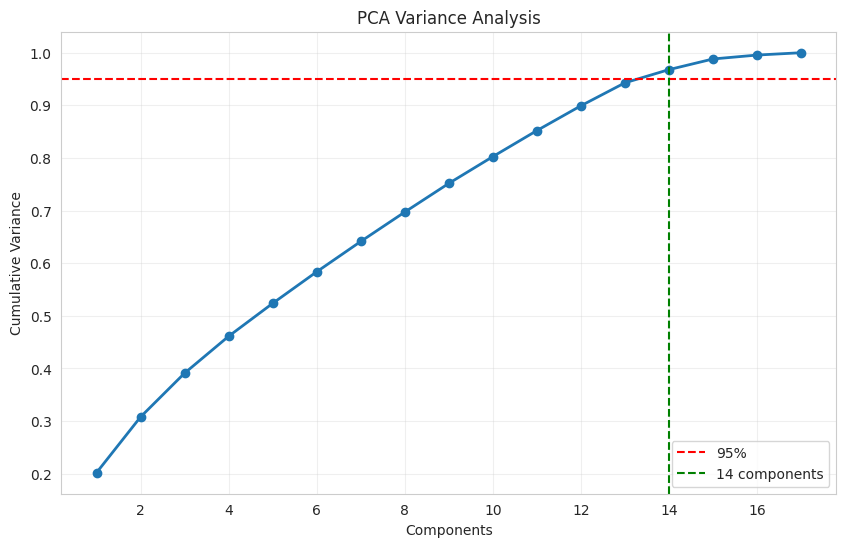

In [20]:

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linewidth=2)
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.axvline(n_comp_95, color='g', linestyle='--', label=f'{n_comp_95} components')
plt.xlabel('Components')
plt.ylabel('Cumulative Variance')
plt.title('PCA Variance Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Test KNN with PCA
pca = PCA(n_components=n_comp_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=optimal_k)
knn_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))

print(f"KNN without PCA: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN with PCA:    {acc_pca:.4f}")
print(f"Difference:      {accuracy_score(y_test, y_pred_knn)-acc_pca:+.4f}")

KNN without PCA: 0.8783
KNN with PCA:    0.8775
Difference:      +0.0008


---\n## Step 13: Apply SMOTE

In [22]:
# Apply SMOTE
print(f"Before SMOTE: {(y_train==0).sum()} vs {(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE:  {(y_train_smote==0).sum()} vs {(y_train_smote==1).sum()}")

# Train KNN on balanced data
knn_smote = KNeighborsClassifier(n_neighbors=optimal_k)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = knn_smote.predict(X_test_scaled)

print(f"\nKNN without SMOTE: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"KNN with SMOTE:    {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"\nRecall improvement: {recall_score(y_test, y_pred_smote)-recall_score(y_test, y_pred_knn):+.4f}")

Before SMOTE: 8338 vs 1526
After SMOTE:  8338 vs 8338

KNN without SMOTE: 0.8783
KNN with SMOTE:    0.7733

Recall improvement: +0.3220


---\n## Step 14: ROC Curves

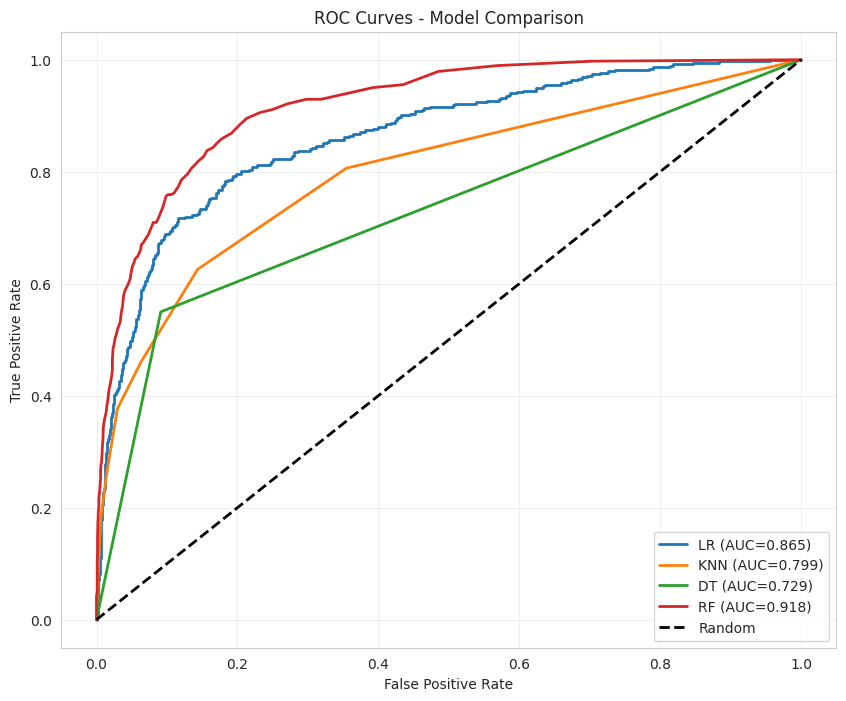

In [23]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, linewidth=2, label=f'LR (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_knn, tpr_knn, linewidth=2, label=f'KNN (AUC={roc_auc_score(y_test, y_prob_knn):.3f})')
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f'DT (AUC={roc_auc_score(y_test, y_prob_dt):.3f})')
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f'RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0,1], [0,1], 'k--', linewidth=2, label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

---\n## Step 15: Summary & Business Insights

In [24]:
print("="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\n1. BEST MODEL: {comparison.loc[comparison['Accuracy'].idxmax(), 'Model']}")
print(f"   Accuracy: {comparison['Accuracy'].max():.4f}")

print(f"\n2. OPTIMAL KNN: K={optimal_k}, Accuracy={accuracy_score(y_test, y_pred_knn):.4f}")

print(f"\n3. CURSE OF DIMENSIONALITY: -{accuracies_noise[0]-accuracies_noise[-1]:.4f} with 200 noise features")

print(f"\n4. PCA: {n_comp_95} components retain {explained_var[n_comp_95-1]*100:.1f}% variance")

print(f"\n5. SMOTE: Improved recall by +{recall_score(y_test, y_pred_smote)-recall_score(y_test, y_pred_knn):.4f}")

print("\n💼 BUSINESS RECOMMENDATIONS:")
print("  • Identify high-intent users for personalized offers")
print("  • Retarget low-intent users with email campaigns")
print("  • Optimize website during high-conversion periods")

print("\n⚖️ ETHICAL CONSIDERATIONS:")
print("  • Ensure transparency in data usage")
print("  • Obtain user consent for tracking")
print("  • Avoid discriminatory targeting")
print("  • Provide opt-out options")

print("\n✓ PROJECT COMPLETED!")

PROJECT SUMMARY

1. BEST MODEL: Random Forest
   Accuracy: 0.9006

2. OPTIMAL KNN: K=7, Accuracy=0.8783

3. CURSE OF DIMENSIONALITY: -0.0215 with 200 noise features

4. PCA: 14 components retain 96.8% variance

5. SMOTE: Improved recall by +0.3220

💼 BUSINESS RECOMMENDATIONS:
  • Identify high-intent users for personalized offers
  • Retarget low-intent users with email campaigns
  • Optimize website during high-conversion periods

⚖️ ETHICAL CONSIDERATIONS:
  • Ensure transparency in data usage
  • Obtain user consent for tracking
  • Avoid discriminatory targeting
  • Provide opt-out options

✓ PROJECT COMPLETED!
